# Classifier BBox Test

`services/forest_mask/cli.py` で追加された `bbox_rgb` を確認するノートブック。

- `services/forest_mask/bbox.py` の `draw_mask_bboxes` で、 `anomaly_context` の連結成分の外接矩形を入力画像に描画する。
- `extract_bboxes` で取り出した `(x, y, w, h)` を `cv2.rectangle` で描く。
- 輪郭 (`draw_mask_contours`) と異なり、矩形のみで囲うため、対象個数や大きさが一目で把握できる。
- `color` / `thickness` を変えて見た目を比較する。
- `mask` / `morph` / `compo` / `context` の各段階の bbox を同条件で描き、後段処理によるノイズ除去の効果を確認する。
- overlay (塗りつぶし) と contour (輪郭) と bbox (矩形) を並べて比較する。

入力: `data/input/jpg/sample/sample_tree.jpg`

In [1]:
# プロジェクトルートで実行できるようにカレントを移動
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
    os.chdir(PROJECT_ROOT)

print("cwd:", Path.cwd())

cwd: /home/mqsol/works/forest-analyzer


In [2]:
# モジュールリロードを有効化
%load_ext autoreload
%autoreload 2

In [3]:
# パラメータ (CLI に合わせる)
INPUT_PATH = Path("data/input/jpg/sample/sample_tree.jpg")

EXG_THRESHOLD = 10.0
SAT_TH = 80.0
LAB_A_TH = 125.0
ANOMALY_SAT_TH = 60.0
ANOMALY_VAL_TH = 170.0
TEXTURE_KERNEL = 5
TEXTURE_TH = 5.0

ANOMALY_CLOSING = 5
ANOMALY_OPENING = 3
HEALTHY_CLOSING = 7
HEALTHY_OPENING = 3
MIN_SIZE = 300

CTX_MIN_SIZE = 30
CTX_MAX_SIZE = 2000
CTX_BUFFER_SIZE = 15
CTX_MIN_HEALTHY_RATIO = 0.4

# bbox 用 (CLI の bbox_rgb はデフォルト引数のまま呼んでいる)
BBOX_COLOR = (255, 0, 0)
BBOX_THICKNESS = 2

In [4]:
# 特徴量計算 -> 分類 -> モルフォロジー -> 連結成分 -> context filter -> bbox
from services.common.image import load_rgb
from services.forest_mask.exg import calc_exg
from services.forest_mask.color import calc_hsv, calc_lab
from services.forest_mask.texture import calc_texture
from services.forest_mask.classifier import classify_forest_status
from services.forest_mask.morphology import apply_morphology
from services.forest_mask.components import remove_small_components
from services.forest_mask.context import filter_components_by_surrounding_healthy
from services.forest_mask.overlay import create_mask_overlay
from services.forest_mask.contour import draw_mask_contours
from services.forest_mask.bbox import draw_mask_bboxes, extract_bboxes

rgb = load_rgb(INPUT_PATH)
exg = calc_exg(rgb)
hsv_h, hsv_s, hsv_v = calc_hsv(rgb)
lab_l, lab_a, lab_b = calc_lab(rgb)
texture = calc_texture(exg, TEXTURE_KERNEL)

healthy_mask, anomaly_mask, unknown_mask = classify_forest_status(
    exg=exg,
    s=hsv_s,
    v=hsv_v,
    lab_a=lab_a,
    texture=texture,
    exg_threshold=EXG_THRESHOLD,
    saturation_threshold=SAT_TH,
    lab_a_threshold=LAB_A_TH,
    anomaly_saturation_threshold=ANOMALY_SAT_TH,
    anomaly_value_threshold=ANOMALY_VAL_TH,
    texture_threshold=TEXTURE_TH,
)
anomaly_morph = apply_morphology(anomaly_mask, ANOMALY_CLOSING, ANOMALY_OPENING)
anomaly_compo = remove_small_components(anomaly_morph, min_size=MIN_SIZE)
healthy_morph = apply_morphology(healthy_mask, HEALTHY_CLOSING, HEALTHY_OPENING)

anomaly_context = filter_components_by_surrounding_healthy(
    anomaly_mask=anomaly_compo,
    healthy_mask=healthy_morph,
    min_size=CTX_MIN_SIZE,
    max_size=CTX_MAX_SIZE,
    buffer_size=CTX_BUFFER_SIZE,
    min_healthy_ratio=CTX_MIN_HEALTHY_RATIO,
)

bbox_rgb = draw_mask_bboxes(
    rgb,
    anomaly_context,
    color=BBOX_COLOR,
    thickness=BBOX_THICKNESS,
)

bboxes = extract_bboxes(anomaly_context)
print(f"bbox shape: {bbox_rgb.shape}, dtype: {bbox_rgb.dtype}")
print(f"bbox count: {len(bboxes)}")

bbox shape: (1534, 2048, 3), dtype: uint8
bbox count: 15


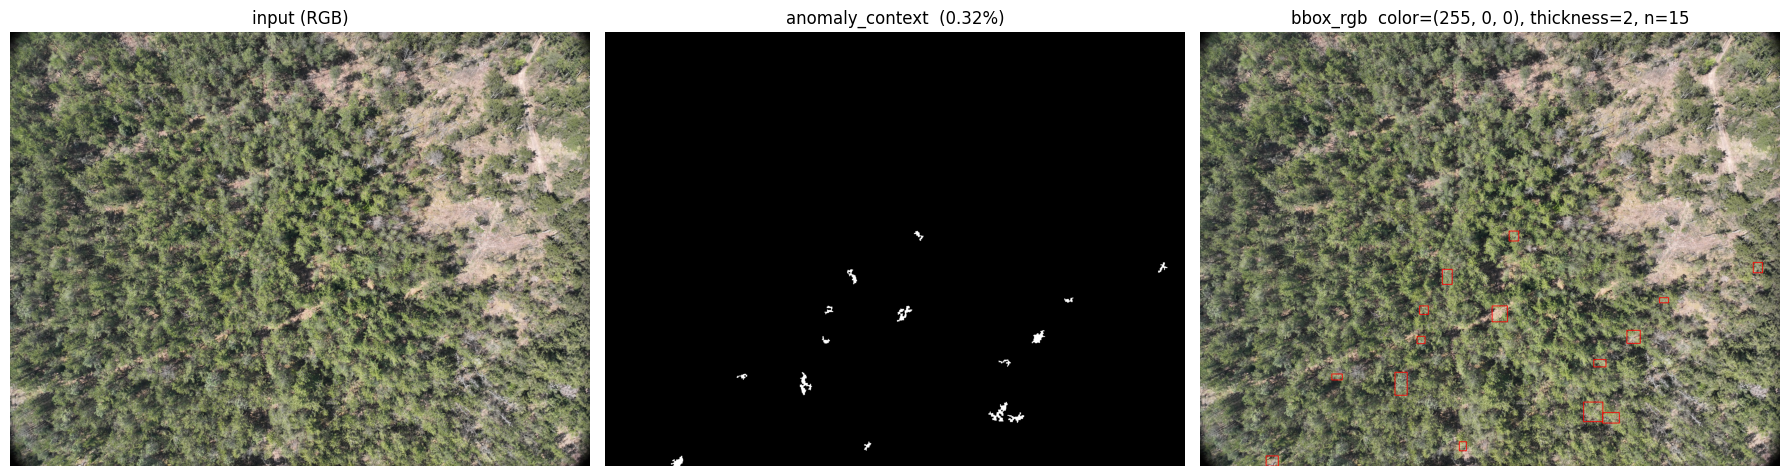

In [5]:
# 入力 / anomaly_context / bbox_rgb を横並びで比較
import matplotlib.pyplot as plt

total = rgb.shape[0] * rgb.shape[1]
pix = int(anomaly_context.sum())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(rgb)
axes[0].set_title("input (RGB)")
axes[0].axis("off")

axes[1].imshow(anomaly_context, cmap="gray", vmin=0, vmax=1)
axes[1].set_title(f"anomaly_context  ({pix / total * 100:.2f}%)")
axes[1].axis("off")

axes[2].imshow(bbox_rgb)
axes[2].set_title(f"bbox_rgb  color={BBOX_COLOR}, thickness={BBOX_THICKNESS}, n={len(bboxes)}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

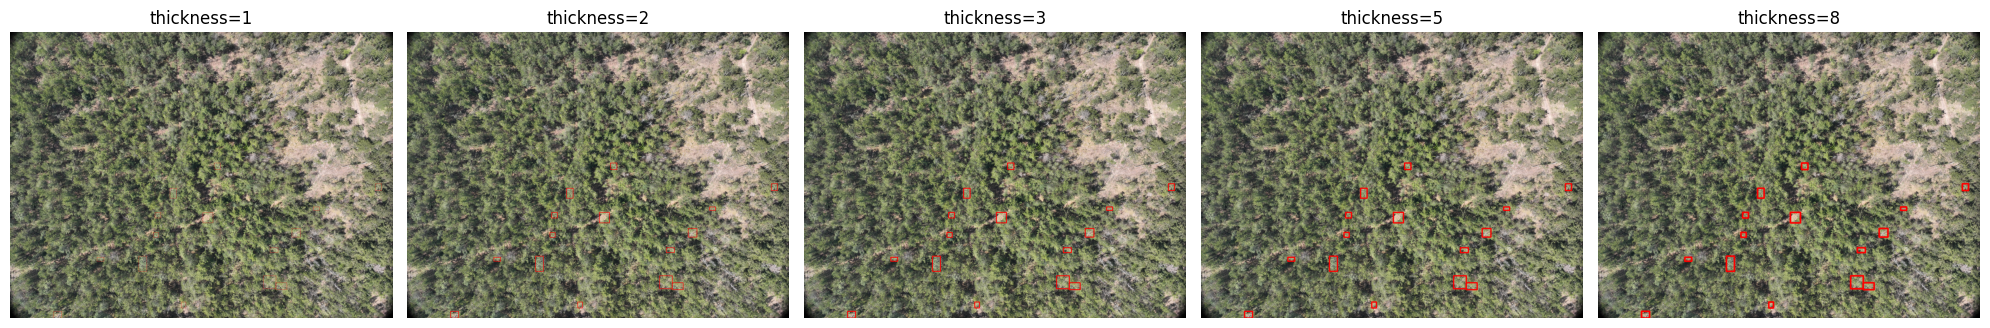

In [6]:
# thickness スイープ
thicknesses = [1, 2, 3, 5, 8]

fig, axes = plt.subplots(1, len(thicknesses), figsize=(4 * len(thicknesses), 5))
for ax, t in zip(axes, thicknesses):
    out = draw_mask_bboxes(rgb, anomaly_context, color=BBOX_COLOR, thickness=t)
    ax.imshow(out)
    ax.set_title(f"thickness={t}")
    ax.axis("off")
plt.tight_layout()
plt.show()

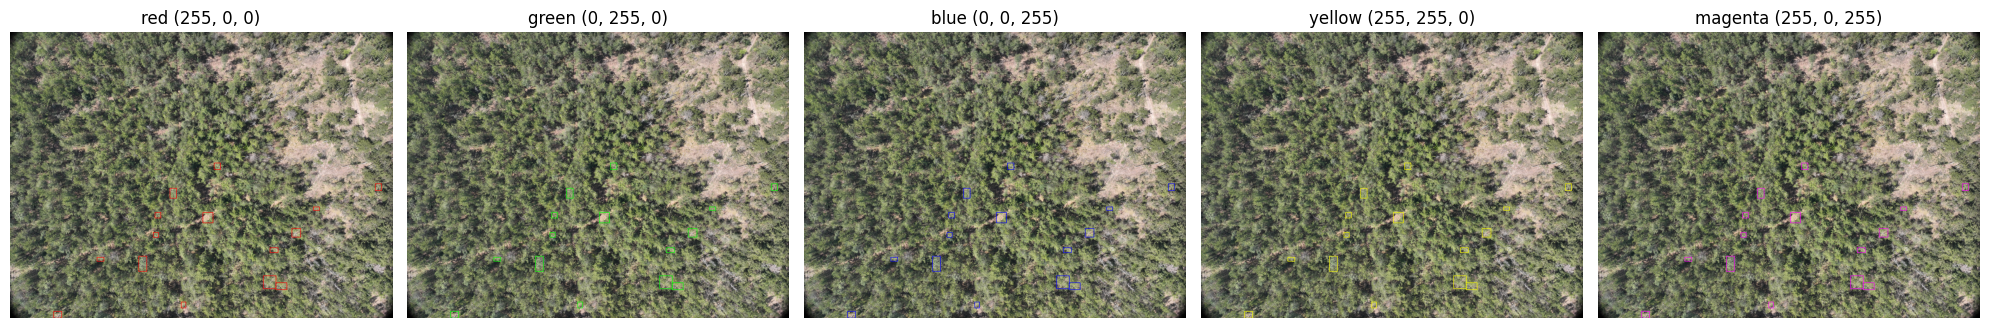

In [7]:
# color スイープ
colors = [
    ("red", (255, 0, 0)),
    ("green", (0, 255, 0)),
    ("blue", (0, 0, 255)),
    ("yellow", (255, 255, 0)),
    ("magenta", (255, 0, 255)),
]

fig, axes = plt.subplots(1, len(colors), figsize=(4 * len(colors), 5))
for ax, (name, c) in zip(axes, colors):
    out = draw_mask_bboxes(rgb, anomaly_context, color=c, thickness=BBOX_THICKNESS)
    ax.imshow(out)
    ax.set_title(f"{name} {c}")
    ax.axis("off")
plt.tight_layout()
plt.show()

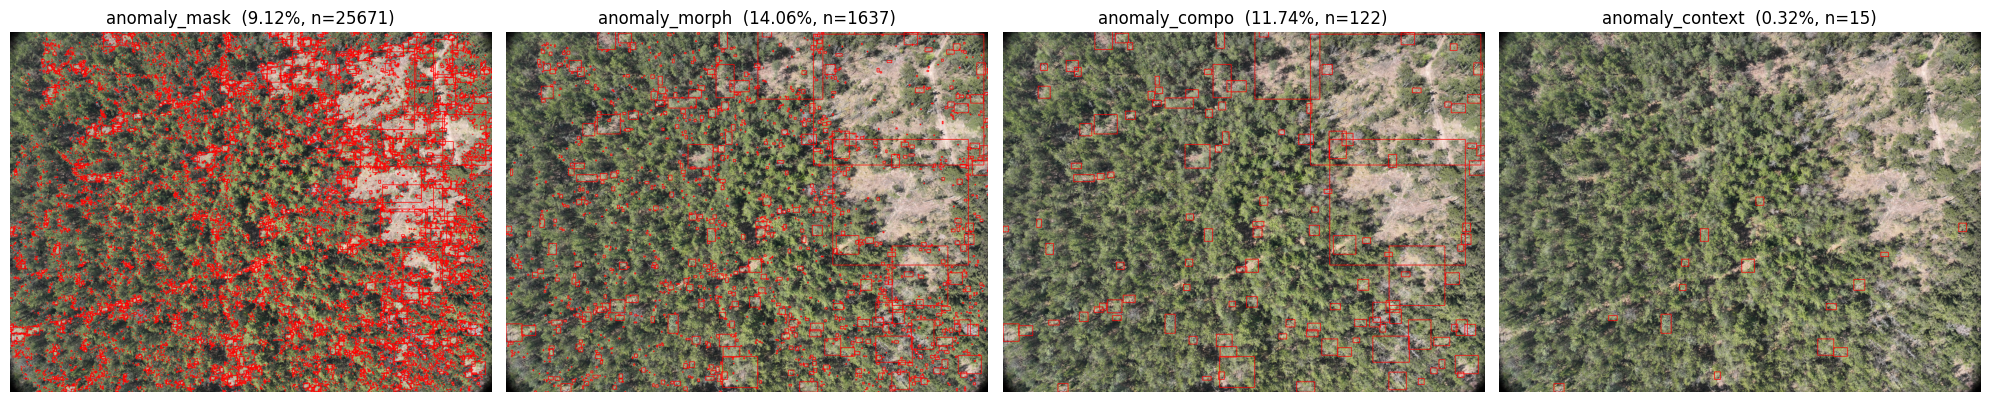

In [8]:
# 後段処理の段階別 bbox (mask -> morph -> compo -> context)
stages = [
    ("anomaly_mask", anomaly_mask),
    ("anomaly_morph", anomaly_morph),
    ("anomaly_compo", anomaly_compo),
    ("anomaly_context", anomaly_context),
]

fig, axes = plt.subplots(1, len(stages), figsize=(5 * len(stages), 6))
for ax, (name, m) in zip(axes, stages):
    out = draw_mask_bboxes(rgb, m, color=BBOX_COLOR, thickness=BBOX_THICKNESS)
    pix = int(m.sum())
    n = len(extract_bboxes(m))
    ax.imshow(out)
    ax.set_title(f"{name}  ({pix / total * 100:.2f}%, n={n})")
    ax.axis("off")
plt.tight_layout()
plt.show()

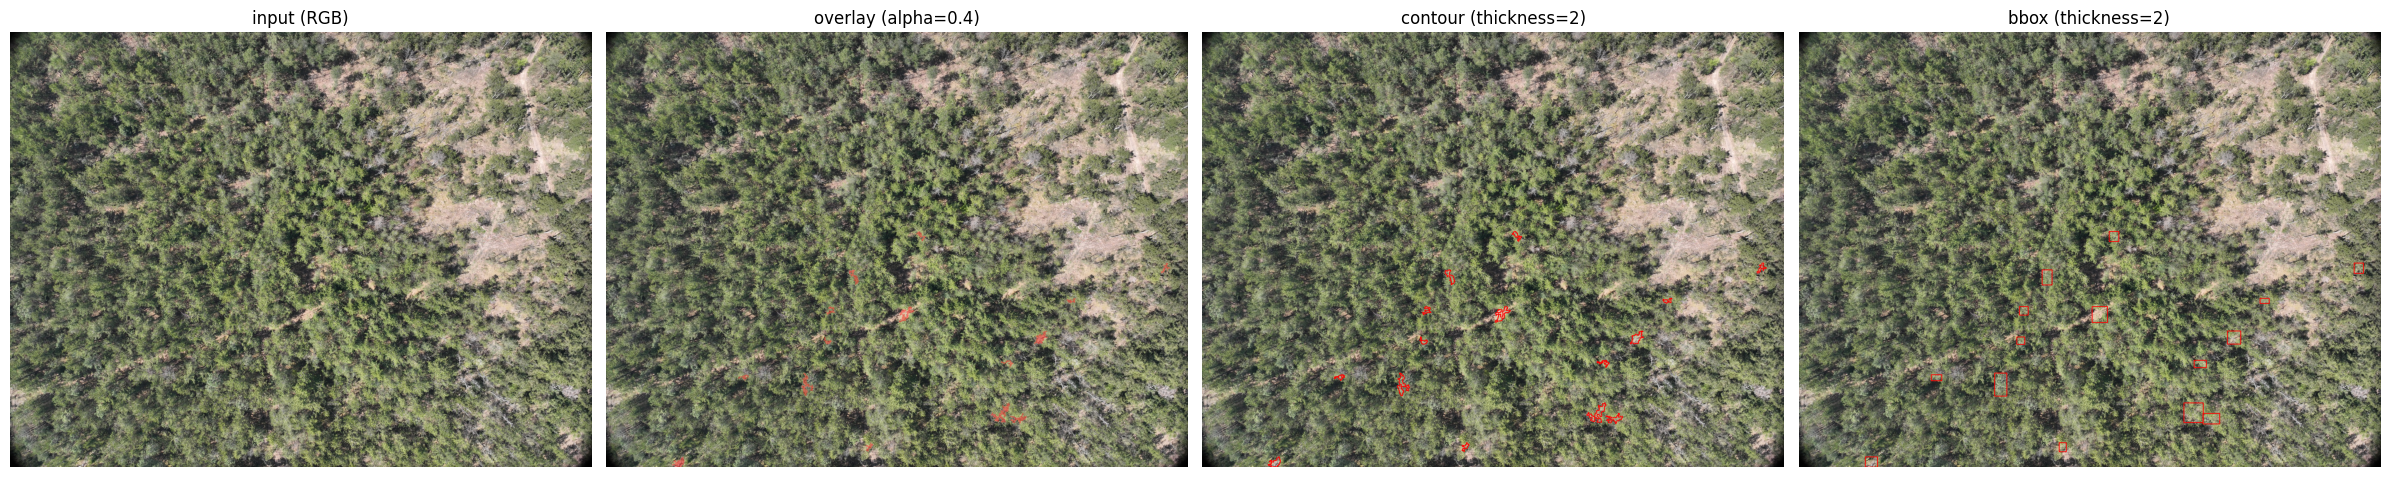

In [9]:
# overlay (塗りつぶし) vs contour (輪郭) vs bbox (矩形) の見え方を比較
overlay_img = create_mask_overlay(rgb, anomaly_context, color=(255, 0, 0), alpha=0.4)
contour_img = draw_mask_contours(rgb, anomaly_context, color=(255, 0, 0), thickness=BBOX_THICKNESS)
bbox_img = draw_mask_bboxes(rgb, anomaly_context, color=(255, 0, 0), thickness=BBOX_THICKNESS)

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
axes[0].imshow(rgb)
axes[0].set_title("input (RGB)")
axes[0].axis("off")
axes[1].imshow(overlay_img)
axes[1].set_title("overlay (alpha=0.4)")
axes[1].axis("off")
axes[2].imshow(contour_img)
axes[2].set_title(f"contour (thickness={BBOX_THICKNESS})")
axes[2].axis("off")
axes[3].imshow(bbox_img)
axes[3].set_title(f"bbox (thickness={BBOX_THICKNESS})")
axes[3].axis("off")
plt.tight_layout()
plt.show()

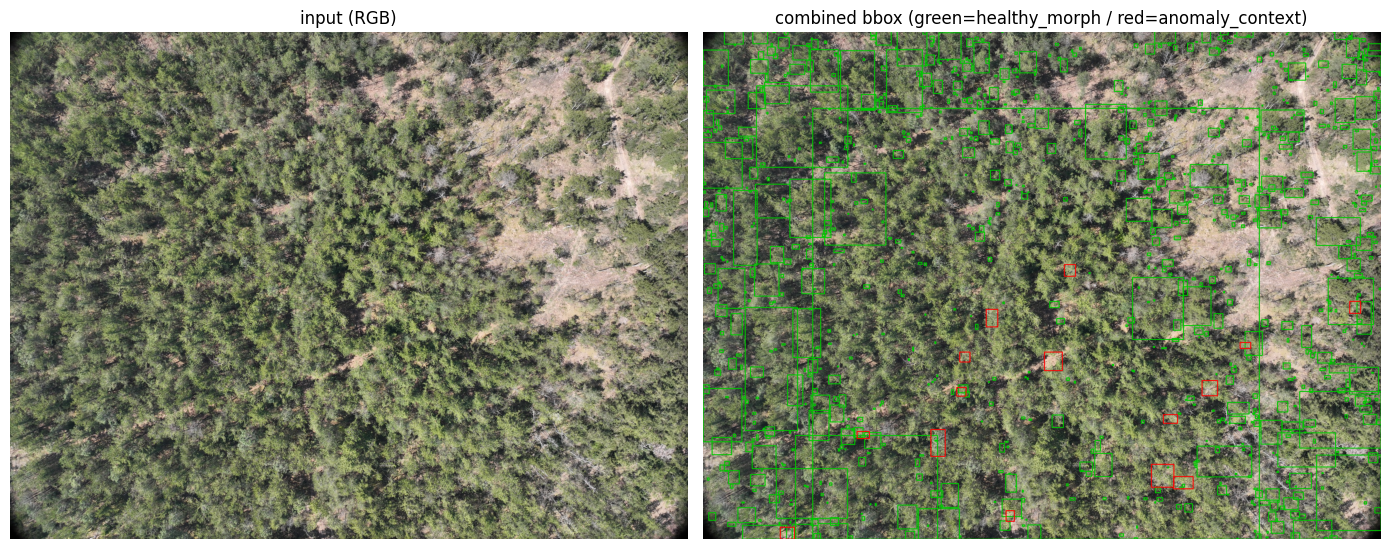

In [10]:
# healthy / anomaly を別色で重ねた合成 bbox
tmp = draw_mask_bboxes(rgb, healthy_morph, color=(0, 200, 0), thickness=BBOX_THICKNESS)
combined = draw_mask_bboxes(tmp, anomaly_context, color=(255, 0, 0), thickness=BBOX_THICKNESS)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(rgb)
axes[0].set_title("input (RGB)")
axes[0].axis("off")
axes[1].imshow(combined)
axes[1].set_title("combined bbox (green=healthy_morph / red=anomaly_context)")
axes[1].axis("off")
plt.tight_layout()
plt.show()